In [9]:
!pip install networkx
!pip install osmnx

In [15]:
import geopandas as gpd
import osmnx as ox
import numpy as np
import networkx as nx
from scipy.spatial import Voronoi, voronoi_plot_2d
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import json
from pathlib import Path

ox.settings.use_cache = True
ox.settings.log_console = True

# the warnings are too annoying 
import warnings
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered",
    category=RuntimeWarning
)
warnings.filterwarnings(
    "ignore",
    category=UserWarning
)

bornholm


/var/folders/vy/l49fzb3j41b_bvyvsvdcjwb40000gn/T/ipykernel_20184/3164717526.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  place_poly = place_gdf.geometry.unary_union


Graph CRS: EPSG:32633
<class 'networkx.classes.multidigraph.MultiDiGraph'>
 Directed: True


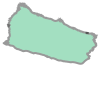

In [16]:
sample = "bornholm"

print (sample)
# Extract polygon of sample municipality
place_gdf = ox.geocode_to_gdf(sample)
place_poly = place_gdf.geometry.unary_union

### GRAPH ###
# Make bike network graph for sample
G = ox.graph_from_place(sample, network_type='bike', retain_all=True) #add simplify=True
G_proj = ox.project_graph(G)
graph_crs = G_proj.graph["crs"]

print ("Graph CRS:", graph_crs)
print(type(G_proj))
print(" Directed:", G_proj.is_directed())

place_gdf.geometry.iloc[0]

bornholm


/var/folders/vy/l49fzb3j41b_bvyvsvdcjwb40000gn/T/ipykernel_20184/2241632554.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  place_poly = place_gdf.geometry.unary_union


<class 'networkx.classes.multidigraph.MultiDiGraph'>
 Directed: True


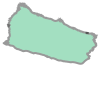

In [17]:
sample = "bornholm"

print (sample)
# Extract polygon of sample municipality
place_gdf = ox.geocode_to_gdf(sample)
place_poly = place_gdf.geometry.unary_union

### GRAPH ###
# Make bike network graph for sample
G = ox.graph_from_place(sample, network_type='bike', retain_all=True) #add simplify=True
G_proj = ox.project_graph(G)
graph_crs = G_proj.graph["crs"]
print(type(G_proj))
print(" Directed:", G_proj.is_directed())

place_gdf.geometry.iloc[0]

In [18]:
PLACE = "Bornholm, Denmark"

sample = "Bornholm, Denmark"
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

print(sample)

Bornholm, Denmark


In [19]:
place_gdf = ox.geocode_to_gdf(sample)
place_poly = place_gdf.geometry.union_all()

place_gdf

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"MULTIPOLYGON (((14.67571 55.09425, 14.67573 55...",14.675709,54.987239,15.156922,55.299121,147084819,relation,5176019,55.143122,14.92263,place,island,17,0.592547,island,Bornholm,"Bornholm, Capital Region of Denmark, Denmark"


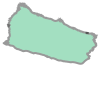

In [20]:
# Display the boundary geometry.
place_gdf.geometry.iloc[0]

In [21]:
# retain_all=True keeps disconnected bike-accessible components.
G = ox.graph_from_polygon(
    place_poly,
    network_type="bike",
    retain_all=True,
    simplify=True,
)

G_proj = ox.project_graph(G)
graph_crs = G_proj.graph["crs"]

print(type(G_proj))
print("Directed:", G_proj.is_directed())
print("CRS:", graph_crs)
print("Nodes:", G_proj.number_of_nodes())
print("Edges:", G_proj.number_of_edges())

<class 'networkx.classes.multidigraph.MultiDiGraph'>
Directed: True
CRS: EPSG:32633
Nodes: 26330
Edges: 61331


In [22]:
graph_path = output_dir / "bornholm_bike_network.graphml"
boundary_path = output_dir / "bornholm_boundary.geojson"

ox.io.save_graphml(G_proj, graph_path)
place_gdf.to_file(boundary_path, driver="GeoJSON")

print("Saved graph to:", graph_path)
print("Saved boundary to:", boundary_path)

Saved graph to: outputs/bornholm_bike_network.graphml
Saved boundary to: outputs/bornholm_boundary.geojson


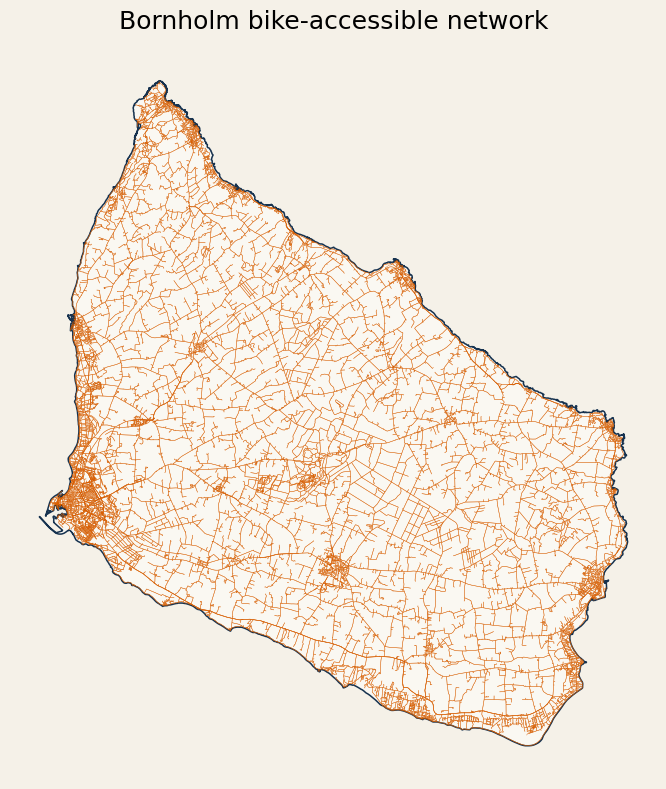

Saved plot to: outputs/bornholm_bike_network.png


In [23]:
boundary_proj = place_gdf.to_crs(graph_crs)
nodes, edges = ox.graph_to_gdfs(G_proj)

fig, ax = plt.subplots(figsize=(10, 8), facecolor="#f5f1e8")

boundary_proj.plot(
    ax=ax,
    facecolor="#faf8f2",
    edgecolor="#16324f",
    linewidth=1.1,
    zorder=1,
)

edges.plot(
    ax=ax,
    color="#d95f02",
    linewidth=0.32,
    alpha=0.82,
    zorder=2,
)

ax.set_title("Bornholm bike-accessible network", fontsize=18, pad=14)
ax.set_axis_off()
fig.tight_layout()

plot_path = output_dir / "bornholm_bike_network.png"
fig.savefig(plot_path, dpi=240, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved plot to:", plot_path)